# ARIMAX — Predikcia priemyselnej produkcie SR

Model s exogennymi premennymi (ARIMAX / SARIMAX). 

Struktura notebooku:
- Importy a konfiguracia
- Nacitanie a cistenie dat
- ADF test stacionarity (`functions.adf_test`)
- ACF / PACF — identifikacia lagov
- BIC forward selection exogennych premennych
- Train / test split (`functions.train_test_split_exog`)
- Odhad ARIMAX modelu
- Diagnostika reziduaov
- Predikcia a hodnotenie (`functions.evaluate_forecast`, `functions.plot_forecast`)

In [8]:
# import potrebnych kniznic a konfiguracia notebooku

import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

import functions
importlib.reload(functions)
from functions import forward_selection
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Importy uspesne.")


Importy uspesne.


In [2]:
# konfiguracia a stiahnutie dat
# vypisanie info o datach a kontrola chybajucich hodnot

DATA_PATH  = r"C:\Users\adamv\Desktop\ADAM\VS\Diplomovka\excel\data.xlsx"
SHEET_NAME = "all"

df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME, engine="openpyxl")

df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")

print(f"Nacitane: {df_raw.shape[0]} riadkov, {df_raw.shape[1]} stlpcov")
print(f"Obdobie : {df_raw.index.min().date()} az {df_raw.index.max().date()}")
print("Stlpce  :", list(df_raw.columns))

missing = df_raw.isnull().sum()
if missing.any():
    print("\nChybajuce hodnoty:")
    print(missing[missing > 0])
else:
    print("\nZiadne chybajuce hodnoty.")


Nacitane: 312 riadkov, 13 stlpcov
Obdobie : 2000-01-01 az 2025-12-01
Stlpce  : ['pp', 'cpi', 'ipcv_priemysel', 'export_celkovy_sa', 'trzby_priemysel_sa', 'kurz_usd_eur', 'sadzba_3m_euribor', 'uvery_celkom', 'vklady_nefinancne_podniky', 'prod_dev', 'prod_exp', 'ind_conf', 'fin_stock']

Ziadne chybajuce hodnoty.


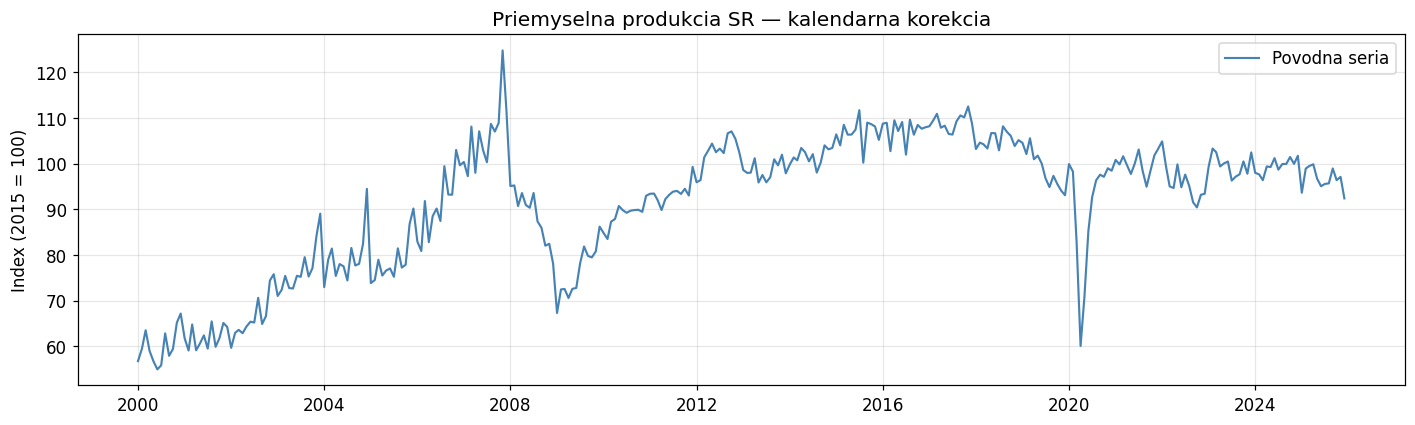

In [ ]:
# graficke porovnanie casovych radov: povodne data vs. SA upravene cez SW JDemtra

df = df_raw.copy()
fig, ax = plt.subplots()
ax.plot(df.index, df["pp"],    color="steelblue",  linewidth=1.4, label="Povodna seria")
ax.plot(df.index, df["pp_sa_new"], color = "green", linewidth = 1.4, label = "Upravena seria by JDemtra", alpha = 0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Priemyselna produkcia SR — kalendarna korekcia")
ax.set_ylabel("Index (2015 = 100)")
ax.legend()
plt.tight_layout()
#plt.savefig("figures/01_cielova_premenna.png", dpi=150)
plt.show()


In [5]:
# kontrola stacionarity premennych
# premenna je stacionarna len ak ADF zamieta H0 A KPSS nezamieta H0.

EXOG_CANDIDATES = df.columns.tolist()

df_to_test = df[EXOG_CANDIDATES].copy()

print("=== ADF test — urovne ===")
non_stationary = functions.adf_test(df)

print("\n=== KPSS test — urovne ===")
for col in EXOG_CANDIDATES:
    stat, pval, _, _ = kpss(df[col].dropna(), regression="c", nlags="auto")
    verdict = "nestacionarna" if pval < 0.05 else "stacionarna"
    print(f"  {col}: stat={stat:.4f}, p={pval:.4f}  [{verdict}]")

print("\nNestacionarne (podla ADF):", non_stationary)


=== ADF test — urovne ===

--- pp ---
ADF stat: -2.4769
p-val: 0.1212
Nezam. H0: nestacionarny

--- cpi ---
ADF stat: 0.8354
p-val: 0.9922
Nezam. H0: nestacionarny

--- ipcv_priemysel ---
ADF stat: -1.0786
p-val: 0.7235
Nezam. H0: nestacionarny

--- export_celkovy_sa ---
ADF stat: -0.3847
p-val: 0.9126
Nezam. H0: nestacionarny

--- trzby_priemysel_sa ---
ADF stat: -0.7802
p-val: 0.8249
Nezam. H0: nestacionarny

--- kurz_usd_eur ---
ADF stat: -2.3097
p-val: 0.1688
Nezam. H0: nestacionarny

--- sadzba_3m_euribor ---
ADF stat: -2.3198
p-val: 0.1657
Nezam. H0: nestacionarny

--- uvery_celkom ---
ADF stat: 1.8306
p-val: 0.9984
Nezam. H0: nestacionarny

--- vklady_nefinancne_podniky ---
ADF stat: 1.3944
p-val: 0.9971
Nezam. H0: nestacionarny

--- prod_dev ---
ADF stat: -5.7978
p-val: 0.0000
Zam. H0: stacionarny

--- prod_exp ---
ADF stat: -3.5767
p-val: 0.0062
Zam. H0: stacionarny

--- ind_conf ---
ADF stat: -4.0928
p-val: 0.0010
Zam. H0: stacionarny

--- fin_stock ---
ADF stat: -2.8459
p-va

In [6]:
# diferencovanie nestacionarnych premennych

df_diff = df[non_stationary].diff(1).dropna()
print("=== ADF test — prve diferencie ===")
non_stationary_diff = functions.adf_test(df_diff)

if non_stationary_diff:
    print("\nPremenné stale nestacionarne po 1. diferencii (zvazit I(2)):")
    print(non_stationary_diff)
else:
    print("\nVsetky premenne su stacionarne po 1. diferencii.")


=== ADF test — prve diferencie ===

--- pp ---
ADF stat: -4.8234
p-val: 0.0000
Zam. H0: stacionarny

--- cpi ---
ADF stat: -3.5451
p-val: 0.0069
Zam. H0: stacionarny

--- ipcv_priemysel ---
ADF stat: -3.8703
p-val: 0.0023
Zam. H0: stacionarny

--- export_celkovy_sa ---
ADF stat: -13.8271
p-val: 0.0000
Zam. H0: stacionarny

--- trzby_priemysel_sa ---
ADF stat: -3.9703
p-val: 0.0016
Zam. H0: stacionarny

--- kurz_usd_eur ---
ADF stat: -12.8393
p-val: 0.0000
Zam. H0: stacionarny

--- sadzba_3m_euribor ---
ADF stat: -4.4214
p-val: 0.0003
Zam. H0: stacionarny

--- uvery_celkom ---
ADF stat: -3.9095
p-val: 0.0020
Zam. H0: stacionarny

--- vklady_nefinancne_podniky ---
ADF stat: -4.0775
p-val: 0.0011
Zam. H0: stacionarny

--- fin_stock ---
ADF stat: -11.6169
p-val: 0.0000
Zam. H0: stacionarny

Vsetky premenne su stacionarne po 1. diferencii.


In [ ]:
# identifikacia poctu lagov
# ACF => MA (q)
# PACF => AR (p)

y_diff = df_diff["pp_sa"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf( y_diff, lags=36, ax=axes[0], title="ACF — delta pp_sa")
plot_pacf(y_diff, lags=36, ax=axes[1], title="PACF — delta pp_sa")
plt.tight_layout()
#plt.savefig("figures/02_acf_pacf.png", dpi=150)
plt.show()


KeyError: 'pp_sa_new'

In [ ]:
#vytvorenie dummy premennej pre fin krizu a odstranenie povodnej premenneh pp

df_diff["crisis_dummy"] = 0
df_diff.loc["2008-01-01", "crisis_dummy"] = 1

#df_diff.drop(columns= ["pp"], inplace = True)

df["crisis_dummy"] = 0
df.loc["2008-01-01", "crisis_dummy"] = 1
# zobrazenie crisis riadku
df_diff[df_diff["crisis_dummy"] == 1]


,cpi,ipcv_priemysel,export_celkovy_sa,trzby_priemysel_sa,kurz_usd_eur,sadzba_3m_euribor,uvery_celkom,vklady_nefinancne_podniky,fin_stock,pp_sa_new,crisis_dummy
datum,,,,,,,,,,,
2008-01-01,1.8239,1.0752,372.9629,356.422,0.015,0.01,699.0,-670.0,1.0,-14.980809,1


In [ ]:
df.to_csv("data_mod.csv", index= False, encoding='utf-8')

In [ ]:
# vyber premennych do modelu na zaklade znizovania BIC
selected_cols = forward_selection(df_diff,"pp_sa")

BIC forward selection:
--------------------------------------------------
  + 'export_celkovy_sa'  BIC = 1483.59
  + 'crisis_dummy'  BIC = 1414.06
  + 'trzby_priemysel_sa'  BIC = 1387.51
  + 'cpi'  BIC = 1386.26
  Zastavenie — pridanie ziadnej premennej nezlepsuje BIC.
--------------------------------------------------
Vybrane premenne: ['export_celkovy_sa', 'crisis_dummy', 'trzby_priemysel_sa', 'cpi']
Finalny BIC    : 1386.26


In [ ]:
# korelacna matica vybranych premennych
#df[selected_cols + ["pp_sa"]].corr()

,export_celkovy_sa,crisis_dummy,trzby_priemysel_sa,cpi,pp_sa_new
export_celkovy_sa,1.000000,-0.014001,0.992234,0.964176,0.719261
crisis_dummy,-0.014001,1.000000,-0.005926,-0.024656,0.023510
trzby_priemysel_sa,0.992234,-0.005926,1.000000,0.964142,0.706740
cpi,0.964176,-0.024656,0.964142,1.000000,0.622178
pp_sa_new,0.719261,0.023510,0.706740,0.622178,1.000000


In [ ]:
# urcenie rozsah testovacej mnoziny a rozdelenie dat na train/test
TEST_SIZE = 24

train_y, test_y, train_exog, test_exog = functions.train_test_split_exog(
    df   = df_diff,
    y_col = "pp_sa",
    exog_cols = selected_cols if selected_cols else None,
    train_ratio = 1 - TEST_SIZE / len(df_diff),
)

print(f"Trenovacia mnozina: {train_y.index.min().date()} az {train_y.index.max().date()} ({len(train_y)} obs.)")
print(f"Testovacia mnozina: {test_y.index.min().date()} az {test_y.index.max().date()} ({len(test_y)} obs.)")


Trenovacia mnozina: 2000-02-01 az 2023-12-01 (287 obs.)
Testovacia mnozina: 2024-01-01 az 2025-12-01 (24 obs.)


In [109]:
# odhad modelu
# enforce_stationarity/invertibility=False — model neobmedzi priestor parametrov, co umoznuje stabilnejsiu konvergenciu.

BASE_ORDER = (1,0,1)
SEAS_ORDER = (0, 0, 0,12)

model_fit = SARIMAX(
    train_y,
    exog              = train_exog,
    order             = BASE_ORDER,
    seasonal_order    = SEAS_ORDER,
    enforce_stationarity  = False,
    enforce_invertibility = False,
).fit(disp=False, cov_type="robust")

print(model_fit.summary()) 


                               SARIMAX Results                                
Dep. Variable:              pp_sa_new   No. Observations:                  287
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -623.394
Date:                Sun, 02 Aug 2026   AIC                           1260.789
Time:                        22:05:04   BIC                           1286.356
Sample:                    02-01-2000   HQIC                          1271.038
                         - 12-01-2023                                         
Covariance Type:               robust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
export_celkovy_sa      0.0066      0.001      6.432      0.000       0.005       0.009
crisis_dummy         -18.6539      1.233    -15.134      0.000     -21.070     -16.238
trzby_priemysel_sa  

datum
2005-01-01   -4.873139
2008-12-01   -3.863641
2009-01-01   -3.755342
2004-11-01   -2.919880
2007-07-01   -2.904671
                ...   
2009-02-01    4.136208
2007-09-01    4.203557
2009-07-01    4.409169
2004-12-01    7.358406
2007-11-01    8.668938
Length: 72, dtype: float64


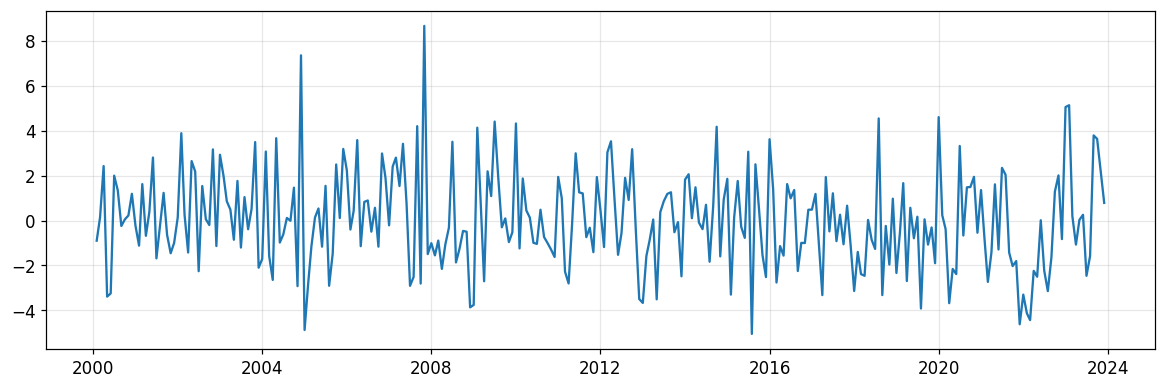

In [110]:
# vizualizacia rezidualov modelu
plt.plot(model_fit.resid)
print(model_fit.resid.loc["2004-01":"2009-12"].sort_values())

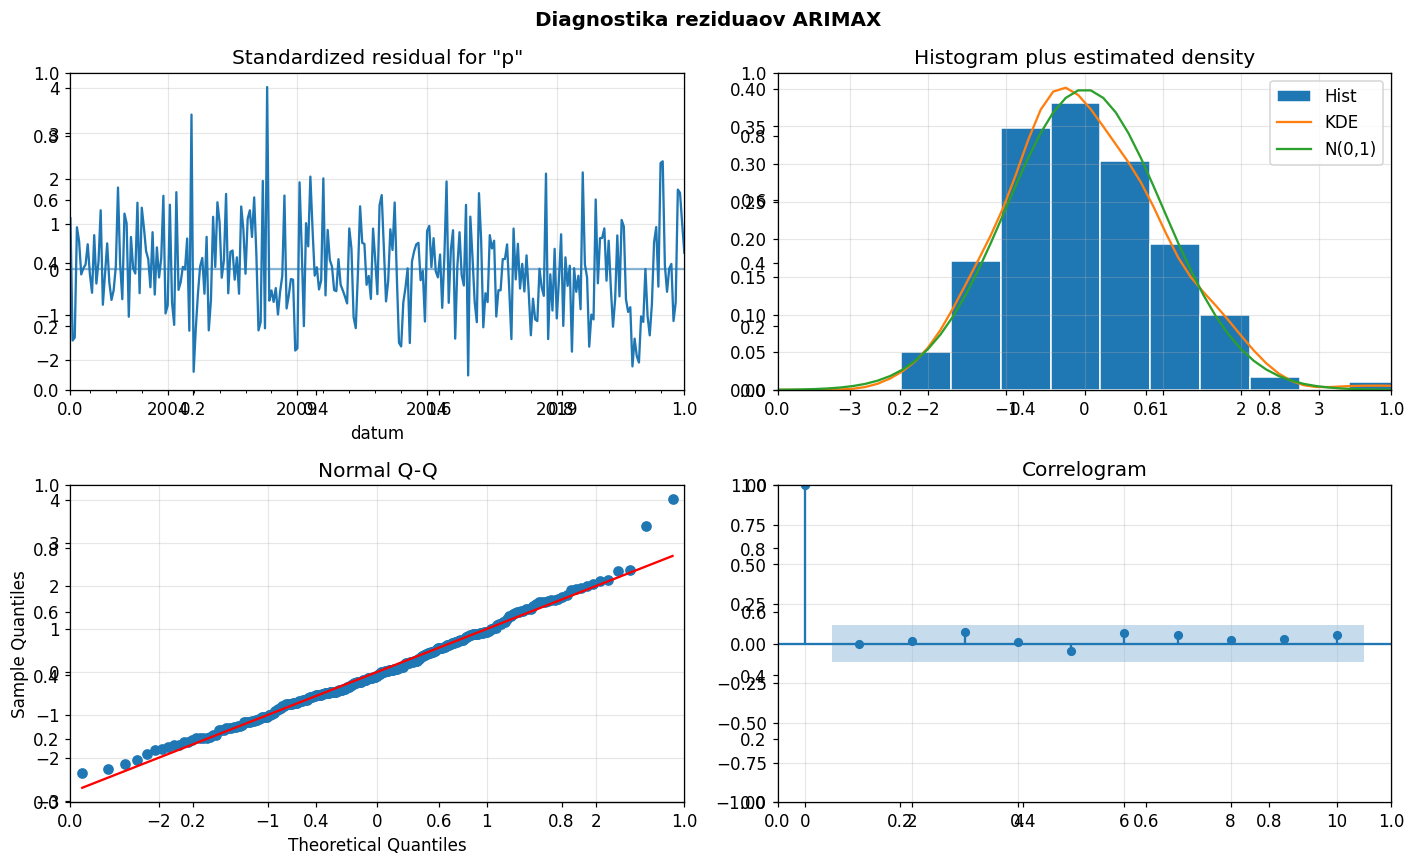


Ljung-Box test (H0: ziadna autokorelacia reziduaov):
      lb_stat  lb_pvalue
12   6.101686   0.910870
24  18.696361   0.767983


In [111]:
# diagnostika rezidualov

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
model_fit.plot_diagnostics(fig=fig)
plt.suptitle("Diagnostika reziduaov ARIMAX", fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("figures/03_diagnostika_rezidualy.png", dpi=150)
plt.show()


residuals = model_fit.resid.dropna()
lb = acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
print("\nLjung-Box test (H0: ziadna autokorelacia reziduaov):")
print(lb.to_string())


In [112]:
# evaluacia modelu cez RMSE, MAPE a ME
last_train_value = train_y.iloc[-1]
forecast = functions.evaluate_forecast(model_fit, test_y, test_exog, last_train_value, original=True)


RMSE: 2.8244
MAPE: 170.58%
ME:   -1.4875


In [113]:
# zobrazenie najvacsich chyb
errors = test_y - forecast
print(errors.sort_values())
print(errors.abs().sort_values(ascending=False).head(10))

datum
2025-01-01   -6.267126
2024-04-01   -1.965562
2025-10-01   -1.575876
2025-11-01   -1.569245
2025-02-01   -1.449517
2025-12-01   -1.444450
2024-10-01   -1.262487
2025-05-01   -1.122762
2024-09-01   -0.830904
2025-09-01   -0.612306
2024-06-01   -0.606887
2025-07-01   -0.338980
2024-03-01   -0.229372
2024-01-01   -0.175324
2024-11-01    0.106805
2024-08-01    0.293910
2025-04-01    0.305394
2025-06-01    0.479531
2025-03-01    0.781521
2024-07-01    0.935353
2024-05-01    1.348029
2024-02-01    1.631469
2025-08-01    3.469401
2024-12-01    4.110766
dtype: float64
datum
2025-01-01    6.267126
2024-12-01    4.110766
2025-08-01    3.469401
2024-04-01    1.965562
2024-02-01    1.631469
2025-10-01    1.575876
2025-11-01    1.569245
2025-02-01    1.449517
2025-12-01    1.444450
2024-05-01    1.348029
dtype: float64


In [114]:
# staticka evaluacia modelu s posunom
train_size  = len(train_y) 
for h in [6, 12, 18, 24]:
    test_h = test_y.iloc[:h]
    test_exog_h = test_exog.iloc[:h]
    
    print(f"--- Horizont {h} ---")
    print("Level (original=True):")
    functions.evaluate_forecast(model_fit, test_h, test_exog_h, last_train_value, original=True)
    print("Delta (original=False):")
    functions.evaluate_forecast(model_fit, test_h, test_exog_h, last_train_value, original=False)

--- Horizont 6 ---
Level (original=True):
RMSE: 0.8730
MAPE: 121.58%
ME:   0.3967
Delta (original=False):
RMSE: 1.2106
MAPE: 107.91%
ME:   0.0004
--- Horizont 12 ---
Level (original=True):
RMSE: 1.2814
MAPE: 85.21%
ME:   0.5575
Delta (original=False):
RMSE: 1.5532
MAPE: 156.05%
ME:   0.2796
--- Horizont 18 ---
Level (original=True):
RMSE: 2.4198
MAPE: 168.70%
ME:   -0.8750
Delta (original=False):
RMSE: 2.0072
MAPE: 124.59%
ME:   -0.2176
--- Horizont 24 ---
Level (original=True):
RMSE: 2.8244
MAPE: 170.58%
ME:   -1.4875
Delta (original=False):
RMSE: 1.9587
MAPE: 137.20%
ME:   -0.2495


In [ ]:
# rolling evaluacia modelu s posunom

results = []
for origin_shift in range(0, 24, 3):   # napr. každé 3 mesiace posun
    train_size_i = train_size - origin_shift
    train_i = df["pp_sa"].iloc[:train_size_i]
    test_i  = df["pp_sa"].iloc[train_size_i:train_size_i+24]
    test_exog_i = df[test_exog_h.columns].iloc[train_size_i:train_size_i+24]
    
    model_i = SARIMAX(train_i, exog=df[test_exog_h.columns].iloc[:train_size_i], order=(1,0,1))
    res_i = model_i.fit(disp=False)
    
    forecast_i = res_i.forecast(steps=24, exog=test_exog_i)
    rmse_i = np.sqrt(np.mean((test_i.values - forecast_i.values)**2))
    results.append(rmse_i)
    print(f"Origin posun {origin_shift}: RMSE={rmse_i:.3f}")

print(f"\nPriemerne RMSE cez vsetky origin body: {np.mean(results):.3f}")

Origin posun 0: RMSE=3.645
Origin posun 3: RMSE=7.856
Origin posun 6: RMSE=3.998
Origin posun 9: RMSE=6.320
Origin posun 12: RMSE=13.994
Origin posun 15: RMSE=10.446
Origin posun 18: RMSE=18.870
Origin posun 21: RMSE=31.393

Priemerne RMSE cez vsetky origin body: 12.065


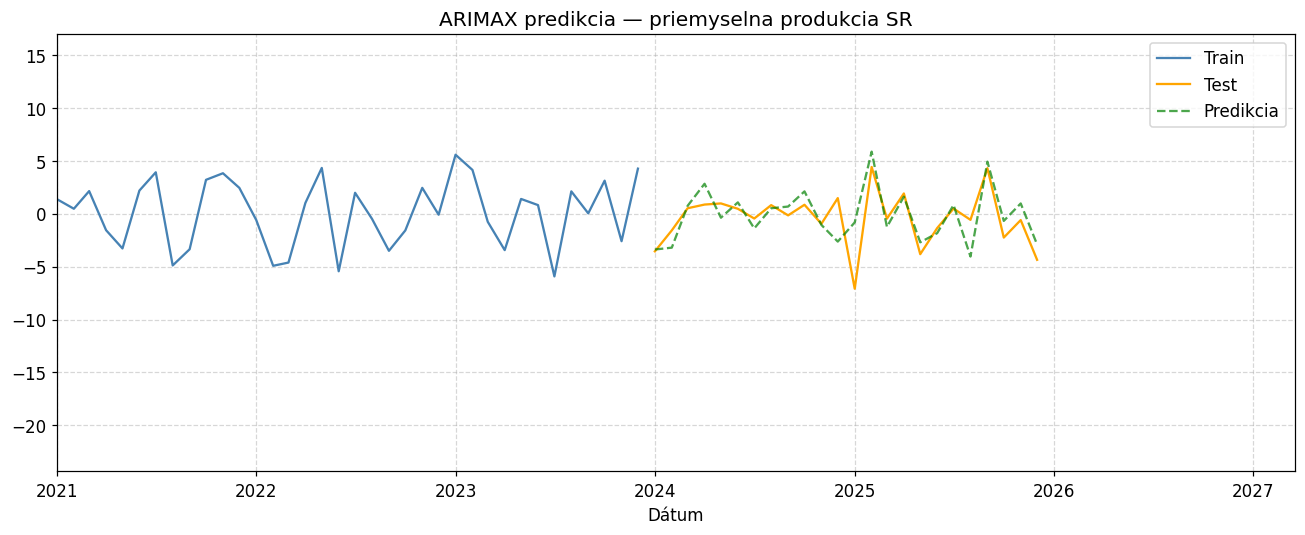

In [117]:
# vizualizacie predikcie

functions.plot_forecast(
    train     = train_y,
    test      = test_y,
    forecast  = forecast,
    title     = f"ARIMAX predikcia — priemyselna produkcia SR",
    zoom_from = test_y.index[0] - pd.DateOffset(months=36),
)

#plt.savefig("figures/04_predikcia_arimax.png", dpi=150, bbox_inches="tight")

